# Contextual Scouting — UEFA Euro 2024
## H3 — Off-Ball Movement

**Hypothesis.** *The vast majority of a player's on-pitch activity occurs out of possession. This investigation seeks to identify players executing high-value attacking runs that are ultimately not capitalised upon by teammates.*

The hypothesis has two halves that have to be measured together:

* **(a) High-value runs** — the player puts themselves in dangerous positions.
* **(b) Not capitalised** — those positions are left unserved by teammates.

For every visible teammate in every 360 freeze frame we compute the H2 calibrated **xEPV** of the hypothetical pass that would have served them. From those event-level values we derive three player-level KPIs:

| KPI | Formula | Reads as |
|---|---|---|
| **Off-Ball Potential / 90** | Σ xEPV / minutes × 90 | volume × quality of off-ball exposure |
| **URS / 90** | Σ xEPV·(1−received) / minutes × 90 | **the latent (uncapitalised) EPV — H3 headline** |
| **Capitalisation rate** | Σ xEPV·received / Σ xEPV | what fraction is realised by teammates |

URS /90 is the single number used to rank players: it combines (a) and (b) in one quantity, in the same EPV units H1 and H2 use, so the leaderboard is directly comparable.  Potential and Capitalisation are the two factors that make URS up; the radar profiles also include **xEPV mean** as the average value-per-frame to separate "few outstanding runs" from "many average ones".

**Pipeline (in order).**

1. **Receiver identity resolution** — anonymous freeze-frame dots are assigned to players via bracket interpolation + Hungarian matching, then validated against StatsBomb's `pass_recipient` on every complete pass in the tournament.
2. **xEPV per visible teammate** — for each *confident*-identified teammate the H2 `compute_xepv` function attaches the same calibrated value H2 attaches to every pass alternative.
3. **Three off-ball KPIs aggregated per player**, normalised per 90' against the H1 minutes pool (272 outfield players, ≥135 min — identical to the H2 DQ pool).

All H1/H2 components are reused as-is (EPV grid, CalibratedXPass, `compute_xepv`, H1 player_totals). **No new Pitch-Control surface** is introduced — H2's xEPV already incorporates the turnover penalty `(1 − xpass) · EPV(mirror)`, so a separate availability filter would double-count the signal.

## Section 0 — Setup

In [1]:
# Make `from src...` work from notebooks/ (mirrors H1/H2 setup).
import sys
from pathlib import Path
_H3 = Path('..').resolve()
if str(_H3) not in sys.path:
    sys.path.insert(0, str(_H3))

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsbombpy import sb

# Tournament match list — used by the validation, calibration and pipeline
# sections below. Loaded once here so every section shares one source.
from src.config import COMPETITION_ID, SEASON_ID
matches = sb.matches(competition_id=COMPETITION_ID, season_id=SEASON_ID)
print(f'Euro 2024: {len(matches)} matches loaded')

Euro 2024: 51 matches loaded


## Section 1 — Receiver identity resolution

**The problem.** StatsBomb 360 free freeze frames carry `x, y` positions but no `player.id`. Aggregating an off-ball metric per player therefore requires recovering each anonymous dot's identity at the instant of the pass.

**The approach.** For each pass we estimate every teammate's position by linearly interpolating between their *previous* and *next* on-ball event (`bracket` mode), then assign names to the anonymous teammate dots by solving a linear-sum-assignment (Hungarian) on the resulting distance matrix. A residual threshold `conf_thr` separates *confident* assignments from the rest.

**The validation.** On complete passes the truth is known (`pass_recipient`). We hide it, let the resolver predict, and report accuracy.

### 1.1 — Resolver implementation

In [2]:
# resolve_receiver lives in src/candidates.py — the same function powers
# the candidates pipeline downstream. We import it here so the harness
# and the notebook share a single source of truth.
from src.candidates import resolve_receiver

### 1.2 — Example: the resolver on one pass

A single freeze frame to see the resolver at work: it names every anonymous teammate dot, flags those it is *confident* about (residual ≤ `CONF_THR_M`), and reports the predicted spatial receiver. We pick an **incomplete** pass (`pass_recipient` is NaN) — the case StatsBomb cannot label and the resolver is built for.

In [3]:
# Self-contained demo: load one match and resolve one incomplete pass.
_m = sb.matches(competition_id=55, season_id=282)
_mid = int(_m['match_id'].iloc[0])
_ev = sb.events(match_id=_mid)
_fr_raw = sb.frames(match_id=_mid, fmt='dict')
_fr = pd.DataFrame(_fr_raw).explode('freeze_frame', ignore_index=True)
_fr = pd.concat([_fr.drop(columns=['freeze_frame']),
                 pd.json_normalize(_fr['freeze_frame'])], axis=1)
_ec = 'event_uuid' if 'event_uuid' in _fr.columns else 'id'
inc = _ev[(_ev['type'] == 'Pass') &
          _ev['pass_recipient'].isna() &
          _ev['pass_end_location'].notna() &
          _ev['id'].isin(_fr[_ec].unique())].head(1)
if len(inc):
    p = inc.iloc[0]
    df_r, pred = resolve_receiver(_ev, _fr, _ec, p['id'])
    if df_r is not None:
        print(f"Match : {_m['home_team'].iloc[0]} vs {_m['away_team'].iloc[0]}")
        print(f"Sender: {p['player']}  ({p['minute']}'{int(p['second']):02d})")
        print(f"Spatial receiver (predicted): {pred}")
        display(df_r[['predicted_player', 'match_residual_m', 'confident',
                      'dist_to_pass_end']].head(6))

Match : Portugal vs Czech Republic
Sender: Pavel Šulc  (25'01)
Spatial receiver (predicted): Unknown


,predicted_player,match_residual_m,confident,dist_to_pass_end
0,Unknown,NaN,False,8.250044
1,David Doudera,29.030098,False,15.423708
2,Vladimír Coufal,25.262008,False,25.239161


### 1.3 — Full-tournament validation (51 matches, headline number)

Gate of §8.5: if `acc-on-confident ≥ 85%` we keep **Tier 1** (per-player URS ranking); otherwise we fall back to Tier 2 (zone/role aggregates). The script also compares the bracket-interpolation v2 resolver against the backward (last-known-location) v1 baseline, using the production parameters from `config.py` (`WINDOW_SECONDS`, `CONF_THR_M`).

Outputs: `data/receiver_resolution_per_match.csv` + `data/receiver_resolution_all_passes.csv`.

In [4]:
from src.validate_receiver_resolution import main as validate_main
validate_main()  # ~5-6 min: 51 matches × ~40 passes × 2 modes

2026-06-01 15:50:34,067  INFO  Matches in competition: 51
2026-06-01 15:50:36,802  INFO    match  1/51  Portugal vs Czech Republic      v2 acc=68.4%  conf=44.7%  acc|conf=94.1%
2026-06-01 15:50:41,230  INFO    match  2/51  Hungary vs Switzerland          v2 acc=66.7%  conf=44.4%  acc|conf=100.0%
2026-06-01 15:50:45,508  INFO    match  3/51  Serbia vs England               v2 acc=78.9%  conf=50.0%  acc|conf=100.0%
2026-06-01 15:50:49,839  INFO    match  4/51  England vs Slovenia             v2 acc=70.3%  conf=51.4%  acc|conf=94.7%
2026-06-01 15:50:53,426  INFO    match  5/51  Croatia vs Italy                v2 acc=65.8%  conf=39.5%  acc|conf=93.3%
2026-06-01 15:50:57,645  INFO    match  6/51  Spain vs Croatia                v2 acc=73.7%  conf=52.6%  acc|conf=95.0%
2026-06-01 15:51:01,627  INFO    match  7/51  Slovenia vs Serbia              v2 acc=65.8%  conf=36.8%  acc|conf=100.0%
2026-06-01 15:51:06,206  INFO    match  8/51  France vs Poland                v2 acc=66.7%  conf=48.7%  ac


  RECEIVER RESOLUTION — 51 matches, sampled ~40 passes / match, W=5.0s, conf_thr=8.0m
  backward:  global acc 17.2%   conf share 16.9%   acc-on-confident 73.9%
  bracket :  global acc 69.1%   conf share 51.1%   acc-on-confident 93.2%

  Tier 1 OK — URS per-player ranking is defensible (acc-on-confident = 93.2% >= 85%).

Saved: /Users/matteovezzoli/Desktop/Contextual-Football-Scouting/Off_Ball_Movement/data/receiver_resolution_per_match.csv
Saved: /Users/matteovezzoli/Desktop/Contextual-Football-Scouting/Off_Ball_Movement/data/receiver_resolution_all_passes.csv


### 1.4 — Parameter calibration

This table is the verdict: the five values frozen in `config.py` and how each was fixed. The two cells that follow are the evidence behind the rows that needed it — the joint sweep (§1.4.1) for the resolver window and threshold, and the empirical pass→receipt distribution (§1.4.2) for the served-window. The last two rows are not free parameters; they are justified in prose right below the table.

| Parameter | Value | How it was chosen |
|---|---|---|
| `WINDOW_SECONDS` | 5 s | Sweep vs `pass_recipient` at the chosen `conf_thr` (§1.4.1) |
| `CONF_THR_M` | 8 m | Fixed on physical grounds, read off the sweep (§1.4.1) |
| `RECEIVED_WINDOW_S` | 4 s | Prudential, ~1 s above the P95 (≈3 s) of pass→receipt time (§1.4.2) |
| `MIN_MINUTES` | 135 | Inherited from H2 to align the player pool (see below) |
| `per_match` (validation) | 40 | Sample-size argument, CI95% ≈ ±1.2 % at n=2040 (see below) |

**`MIN_MINUTES = 135` is inherited, not tuned.** The threshold comes from H2 (`Decision_Quality.config.ANALYSIS_MIN_MINUTES`). H3 reuses it — and reads `macro_role` from the same H1 aggregate H2 reads — so the URS pool *is identical to the H2 pool*: the same 272 outfield players, the same role assignment. Calibrating it independently would silently change the pool and break direct comparability with H2. It is therefore not a free parameter for H3.

**`per_match = 40` in the validation harness is a sample size, not a model parameter.** With 51 matches × 40 passes = 2 040 evaluations, the 95 % confidence interval on a proportion near 0.92 is

$$ 1.96 \cdot \sqrt{\frac{p(1-p)}{n}} \;=\; 1.96 \cdot \sqrt{\frac{0.92 \cdot 0.08}{2040}} \;\approx\; \pm 1.2\,\% . $$

Sharp enough to separate the v2 bracket resolver from the v1 backward baseline (≈ 72 %) with no overlap of confidence intervals. Raising it to 60 would buy ≈ 0.4 % more precision for 50 % more run-time — not worth it.

### 1.4.1 — Sweep of `WINDOW_SECONDS` × `CONF_THR_M`

An extended sweep over 10 matches (≈ 600 passes per grid cell), with the window grid down to 4 s and `conf_thr` from 5 to 12 m. Matches use a fixed seed, different from §1.3 so the validation set does not leak into the calibration.

`conf_thr` is fixed at **8 m** on physical grounds: the mean localisation residual of confident dots there is ~4 m (8 m is the ceiling, not the typical error) and accuracy is ~96 %. Loosening to 12 m maximises the naive `acc_conf · conf_share` objective but admits residuals too large to attribute an xEPV to a specific player; tightening to 6 m does not raise accuracy and drops ~17 % of candidates.

At `conf_thr = 8 m`, accuracy on confident dots rises as the window tightens (88 % at 20 s, 96 % at 5 s) while the confident-candidate volume stays flat (~1.0× across all windows). A shorter window gives fresher position estimates without losing volume, so **`WINDOW_SECONDS = 5 s`** (4 s, the grid floor, is essentially tied). The URS /90 ranking is stable across the window (Spearman ρ ≈ 0.96 between 20 s and 5 s), so this sharpens per-candidate accuracy without reshuffling the leaderboard. Saved to `data/calibration_W_thr.csv`.

In [5]:
# Joint sweep — 10 matches, extended grid, fixed seed.
# The resolver is run ONCE per (pass, W) with an open threshold; the conf_thr
# cutoffs are then applied in pandas — so testing several thr values does not
# re-run the resolver. We also record the mean localisation residual of the
# confident dots (resid_mean_conf): the physical quantity behind the choice.
from src.candidates import resolve_receiver as _resolve

CAL_RNG = np.random.default_rng(7)            # different seed from §1.3 (42)
CAL_N_MATCHES = 10
CAL_PER_MATCH = 60                            # sampled passes per match
W_GRID   = [4.0, 5.0, 6.0, 8.0, 12.0, 20.0]   # extended DOWN to 4 s
THR_GRID = [5.0, 6.0, 8.0, 12.0]              # includes 6 m

cal_matches = matches.sample(n=CAL_N_MATCHES, random_state=7).reset_index(drop=True)
print(f"Calibration matches ({CAL_N_MATCHES}):")
print(cal_matches[['home_team','away_team']].to_string())

raw = []
for _, m in cal_matches.iterrows():
    mid = int(m['match_id'])
    try:
        ev = sb.events(match_id=mid)
        fr_raw = sb.frames(match_id=mid, fmt='dict')
    except Exception as e:
        print(f"  skip {mid}: {e}"); continue
    if not fr_raw: continue
    fr = pd.DataFrame(fr_raw).explode('freeze_frame', ignore_index=True)
    fr = pd.concat([fr.drop(columns=['freeze_frame']),
                    pd.json_normalize(fr['freeze_frame'])], axis=1)
    evc = 'event_uuid' if 'event_uuid' in fr.columns else 'id'
    # Open play only (pass_type NaN) + non-GK sender — SAME universe the
    # production pipeline runs on (candidates.main), so the calibration is
    # measured on exactly the events the resolver will face.
    ps  = ev[(ev['type'] == 'Pass') & (ev['pass_type'].isna())].copy()
    ps  = ps[ps['pass_recipient'].notna() &
             (ps['pass_body_part'].fillna('') != 'Head') &
             ps['pass_end_location'].notna() &
             ps['id'].isin(fr[evc].unique()) &
             (ps['position'] != 'Goalkeeper')]
    if len(ps) == 0: continue
    sn = min(CAL_PER_MATCH, len(ps))
    sample = ps.iloc[CAL_RNG.choice(len(ps), size=sn, replace=False)]
    for W in W_GRID:
        for _, p in sample.iterrows():
            df_r, pred = _resolve(ev, fr, evc, p['id'], W=W, conf_thr=999, mode='bracket')
            if df_r is None: continue
            top = df_r.iloc[0]   # spatial receiver = closest to pass end
            raw.append({'W': W,
                        'residual': float(top['match_residual_m']),
                        'hit': (pred == p['pass_recipient'])})

raw = pd.DataFrame(raw)
rows = []
for W in W_GRID:
    sub = raw[raw['W'] == W]; n = len(sub)
    for thr in THR_GRID:
        conf = sub[sub['residual'] <= thr]
        rows.append({'W': W, 'thr': thr, 'n': n, 'acc': sub['hit'].mean(),
                     'cn': len(conf), 'conf_share': len(conf)/n if n else 0,
                     'acc_conf': conf['hit'].mean() if len(conf) else np.nan,
                     'resid_mean_conf': conf['residual'].mean() if len(conf) else np.nan})
agg = pd.DataFrame(rows)
agg['score'] = agg['acc_conf'] * agg['conf_share']

print('\n=== Full sweep (sorted by acc_conf · conf_share) ===')
print(agg.sort_values('score', ascending=False).round(3).to_string(index=False))

# --- Selection (two steps, NOT a raw argmax of the objective) -----------------
# The objective acc_conf · conf_share rewards COVERAGE, so it drifts to the
# loosest threshold (thr=12) — but a 12 m localisation residual is too weak to
# attribute an xEPV to a specific player. We therefore FIX conf_thr on physical
# grounds first, then read the best window at that threshold.
CHOSEN_THR = 8.0    # mean confident residual ~4 m here; 6 m drops ~17% candidates without raising accuracy
at_thr = agg[agg['thr'] == CHOSEN_THR].sort_values('acc_conf', ascending=False)
print(f"\n=== At the physically-chosen conf_thr = {CHOSEN_THR:g} m, by accuracy ===")
print(at_thr[['W','conf_share','acc_conf','resid_mean_conf']].round(3).to_string(index=False))
best = at_thr.iloc[0]
print(f"\n>>> Chosen: W = {best['W']:g} s, conf_thr = {CHOSEN_THR:g} m  "
      f"(acc_conf = {best['acc_conf']:.1%}, conf_share = {best['conf_share']:.1%}, "
      f"mean residual = {best['resid_mean_conf']:.1f} m)")
print("    Accuracy rises monotonically as W tightens; confident-volume is flat,")
print("    so the smallest window gives the cleanest candidates at no volume cost.")
agg.to_csv('../data/calibration_W_thr.csv', index=False)

Calibration matches (10):
        home_team    away_team
0         Germany      Denmark
1        Portugal     Slovenia
2          Turkey      Georgia
3        Slovenia      Denmark
4          Turkey     Portugal
5  Czech Republic       Turkey
6         Germany      Hungary
7          France      Belgium
8         Hungary  Switzerland
9           Spain      England

=== Full sweep (sorted by acc_conf · conf_share) ===
   W  thr   n   acc  cn  conf_share  acc_conf  resid_mean_conf  score
 4.0 12.0 551 0.681 339       0.615     0.956            4.710  0.588
 5.0 12.0 574 0.692 359       0.625     0.936            4.930  0.585
 6.0 12.0 588 0.687 367       0.624     0.921            4.993  0.575
 8.0 12.0 594 0.675 367       0.618     0.902            5.029  0.557
12.0 12.0 597 0.667 367       0.615     0.880            5.077  0.541
20.0 12.0 599 0.654 370       0.618     0.862            5.111  0.533
 4.0  8.0 551 0.681 288       0.523     0.955            3.873  0.499
 5.0  8.0 574 0.692

### 1.4.2 — Empirical calibration of `RECEIVED_WINDOW_S`

A teammate counts as *served* if their next ball-touch falls within `RECEIVED_WINDOW_S` seconds of the pass. There is no ground truth for the right value, but the distribution of pass→receipt time on completed passes is observable. The cell below computes it across the tournament; its P95 is ≈ 3 s.

**`RECEIVED_WINDOW_S = 4 s`**, one second above the P95. This captures ~96 % of completed-pass receipts and is the plausible time for the ball to reach a moving teammate on a built-up play. Below 3 s, slightly-late receptions get flagged as unserved; above 5 s, the window starts absorbing the next action.

**Robustness.** The exact value is not critical. The cell after the distribution rebuilds the URS /90 ranking for N ∈ {2, 3, 4, 5, 7} s and reports the Spearman ρ of each against the N = 4 s reference. ρ ≥ 0.95 on the immediate neighbours (3 s, 5 s) means the leaderboard does not hinge on the exact choice of N. (It reuses the xEPV parquet from §3, so re-run it only after §3 has produced that file.)

Pass → receipt Δt — n = 18,436 completed passes from 25 matches
  mean   : 1.62 s
  median : 1.00 s
  P75    : 2.00 s
  P90    : 2.00 s
  P95    : 3.00 s
  P99    : 7.00 s


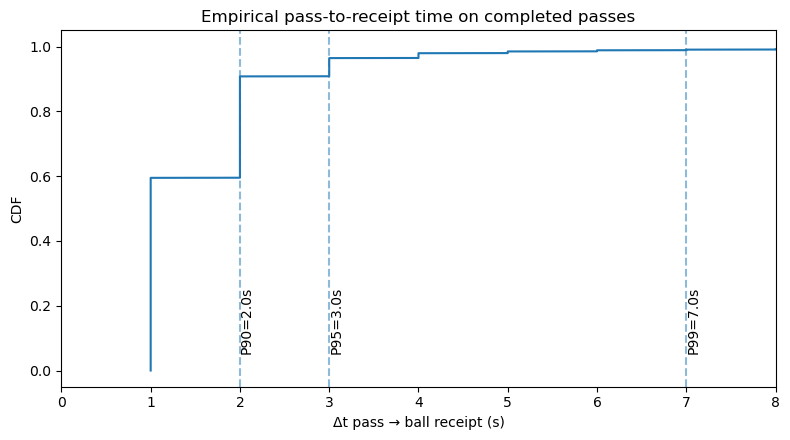


>>> Recommended RECEIVED_WINDOW_S = round(P95) = 3 s


In [6]:
# Empirical distribution of pass → receipt time on completed passes.
# Build it from events: for each completed pass, find the next Ball Receipt
# event by the declared pass_recipient and take Δt.

NB_SAMPLE_MATCHES_FOR_DT = 25     # 25 / 51 is enough to estimate percentiles tightly
dt_matches = matches.sample(n=NB_SAMPLE_MATCHES_FOR_DT, random_state=11).reset_index(drop=True)

dts = []
for _, m in dt_matches.iterrows():
    try:
        ev = sb.events(match_id=int(m['match_id']))
    except Exception:
        continue
    ev = ev.sort_values(['period','minute','second']).reset_index(drop=True)
    ev['t_abs'] = ev['minute'].astype(float)*60 + ev['second'].astype(float)
    # Open play only + non-GK sender, consistent with the pipeline.
    p = ev[(ev['type']=='Pass') & (ev['pass_type'].isna()) &
           (ev['pass_body_part'].fillna('') != 'Head') &
           ev['pass_recipient'].notna() & (ev['position']!='Goalkeeper')]
    # next Ball Receipt of pass_recipient after each pass
    br = ev[ev['type']=='Ball Receipt*'][['player','t_abs','period']]
    for _, row in p.iterrows():
        cand = row['pass_recipient']
        t0   = float(row['t_abs'])
        per  = row['period']
        future = br[(br['player']==cand) & (br['period']==per) &
                    (br['t_abs']>t0) & (br['t_abs']<=t0+15)]   # 15 s safe upper bound
        if len(future)>0:
            dts.append(float(future.iloc[0]['t_abs']) - t0)

dts = np.array(dts)
print(f"Pass → receipt Δt — n = {len(dts):,} completed passes from {NB_SAMPLE_MATCHES_FOR_DT} matches")
print(f"  mean   : {dts.mean():.2f} s")
print(f"  median : {np.median(dts):.2f} s")
print(f"  P75    : {np.percentile(dts,75):.2f} s")
print(f"  P90    : {np.percentile(dts,90):.2f} s")
print(f"  P95    : {np.percentile(dts,95):.2f} s")
print(f"  P99    : {np.percentile(dts,99):.2f} s")

# Visual: CDF
fig, ax = plt.subplots(figsize=(8,4.5))
ax.plot(np.sort(dts), np.linspace(0,1,len(dts)), lw=1.5)
for q,lab in [(.90,'P90'), (.95,'P95'), (.99,'P99')]:
    v = np.percentile(dts, q*100)
    ax.axvline(v, ls='--', alpha=.5); ax.text(v, 0.05, f"{lab}={v:.1f}s", rotation=90, va='bottom')
ax.set_xlabel('Δt pass → ball receipt (s)'); ax.set_ylabel('CDF')
ax.set_title('Empirical pass-to-receipt time on completed passes')
ax.set_xlim(0, max(8, np.percentile(dts,99)+1)); plt.tight_layout(); plt.show()

N_RECOMMENDED = round(np.percentile(dts, 95))
print(f"\n>>> Recommended RECEIVED_WINDOW_S = round(P95) = {N_RECOMMENDED} s")

In [7]:
# Robustness of RECEIVED_WINDOW_S (promised in §1.4.2 above):
# how stable is the URS_per90 ranking when we move N around?
# Rebuilds the `received` flag at several N values on the xEPV parquet that
# Section 3 has produced, then recomputes URS_per90 for each and reports
# Spearman ρ vs the production default (N = 4 s).

from scipy.stats import spearmanr
from src.config import H1_PLAYER_AGG, MIN_MINUTES

xepv_df = pd.read_parquet('../data/off_ball_xepv.parquet')
h1 = pd.read_csv(H1_PLAYER_AGG,
                 usecols=['player','team','primary_role','macro_role','minutes_played'])

# Build events cache ONCE; reuse across all N.
ev_cache = {}
for mid in xepv_df['match_id'].unique():
    try:
        ev_cache[int(mid)] = sb.events(match_id=int(mid))
    except Exception:
        pass

def urs_per_player_at_N(xepv_df, ev_cache, N_seconds):
    df = xepv_df.copy()
    received = pd.Series(False, index=df.index)
    for match_id, grp in df.groupby('match_id'):
        if match_id not in ev_cache: continue
        ev = ev_cache[match_id].copy()
        ev['t_abs'] = ev['minute'].astype(float)*60 + ev['second'].astype(float)
        for idx, row in grp.iterrows():
            t0   = float(row['minute'])*60 + float(row['second'])
            cand = row['player']
            future = ev[(ev['t_abs']>t0) & (ev['t_abs']<=t0+N_seconds)]
            if len(future)>0 and future.iloc[0].get('player')==cand:
                received.at[idx] = True
    df['received'] = received
    df['urs'] = df['xepv'] * (1 - df['received'].astype(float))
    agg = (df.groupby('player')
             .agg(team=('team','first'), urs_sum=('urs','sum'))
             .reset_index()
             .merge(h1, on=['player','team'], how='inner'))
    # macro_role read straight from H1 (per-event role mode), GKs already
    # dropped by H1 — no recompute from primary_role.
    elig = agg['minutes_played'] >= MIN_MINUTES
    agg.loc[~elig, 'urs_sum'] = np.nan
    agg['urs_per90'] = agg['urs_sum']/agg['minutes_played'].replace(0, np.nan)*90
    return agg.set_index('player')['urs_per90'].dropna()

N_VALUES = [2, 3, 4, 5, 7]
rankings = {N: urs_per_player_at_N(xepv_df, ev_cache, N) for N in N_VALUES}

ref_N = 4
ref = rankings[ref_N]
print(f"Spearman ρ of URS_per90 ranking vs N = {ref_N} s (production default):")
for N in N_VALUES:
    common = ref.index.intersection(rankings[N].index)
    rho, _ = spearmanr(ref.loc[common], rankings[N].loc[common])
    print(f"   N = {N}s   ρ = {rho:.3f}   (n = {len(common)})")
print("\nA ρ ≥ 0.95 on the immediate neighbours (3 s and 5 s) confirms that the choice of N = 4 s is robust to ±1 s — small changes do not reorder the leaderboard.")

Spearman ρ of URS_per90 ranking vs N = 4 s (production default):
   N = 2s   ρ = 0.999   (n = 272)
   N = 3s   ρ = 0.999   (n = 272)
   N = 4s   ρ = 1.000   (n = 272)
   N = 5s   ρ = 1.000   (n = 272)
   N = 7s   ρ = 0.999   (n = 272)

A ρ ≥ 0.95 on the immediate neighbours (3 s and 5 s) confirms that the choice of N = 4 s is robust to ±1 s — small changes do not reorder the leaderboard.


## Section 2 — Candidates pipeline (full tournament)

Apply the resolver to every open-play pass with a 360 freeze frame across all 51 matches. The output is `data/off_ball_candidates.parquet`: one row per (sender, candidate teammate) with the resolver's `confident` flag, the candidate's predicted position, and the H2 `xpass` toward that teammate as a hypothetical target.

In [8]:
# Build the candidates parquet for all 51 matches.
from src.candidates import main as candidates_main
candidates_main()

cand = pd.read_parquet('../data/off_ball_candidates.parquet')
print(f'Candidates: {len(cand):,} rows, {cand["event_id"].nunique():,} events, '
      f'{cand["player"].nunique()} unique teammates')

2026-06-01 15:57:20,879  INFO  xPass scored on the fly with H2's CalibratedXPass (event_id-independent; robust to StatsBomb re-pulls).
2026-06-01 15:57:20,885  INFO  Euro 2024 — 51 matches to process
2026-06-01 15:57:20,885  INFO  [1/51] Portugal vs Czech Republic  (id=3930166)
2026-06-01 15:57:43,049  INFO    754 confident candidate rows added
2026-06-01 15:57:43,050  INFO  [2/51] Hungary vs Switzerland  (id=3930159)


  events expanded: 486 / 486  -> 3,721 candidates


2026-06-01 15:58:05,046  INFO    761 confident candidate rows added
2026-06-01 15:58:05,046  INFO  [3/51] Serbia vs England  (id=3930163)


  events expanded: 494 / 494  -> 3,624 candidates


2026-06-01 15:58:32,090  INFO    1200 confident candidate rows added
2026-06-01 15:58:32,090  INFO  [4/51] England vs Slovenia  (id=3930181)


...

  events expanded: 400 / 400  -> 2,956 candidates


2026-06-01 16:19:03,686  INFO    605 confident candidate rows added
2026-06-01 16:19:03,686  INFO  [51/51] Germany vs Scotland  (id=3930158)


  events expanded: 400 / 400  -> 2,891 candidates


2026-06-01 16:19:31,201  INFO    1052 confident candidate rows added
2026-06-01 16:19:31,326  INFO  Saved /Users/matteovezzoli/Desktop/Contextual-Football-Scouting/Off_Ball_Movement/data/off_ball_candidates.parquet  (47257 rows, 29629 events, 475 players)


  events expanded: 639 / 639  -> 4,289 candidates
Candidates: 47,257 rows, 29,629 events, 475 unique teammates


## Section 3 — xEPV per teammate (H2 reused)

Once the identity is known, every visible teammate becomes a *hypothetical* pass target. H2's `compute_xepv` attaches the same calibrated value to it:

$$ \mathrm{xEPV} \;=\; \mathrm{xpass} \cdot \mathrm{EPV}(\text{target}) \;-\; (1-\mathrm{xpass}) \cdot \text{scale} \cdot \mathrm{EPV}(\text{mirror}) $$

No new Pitch-Control surface is needed: the turnover penalty in the second term already captures "the pass might fail". The pipeline keeps only resolver-*confident* candidates (residual ≤ 8 m), which the §1.3 harness validates at ~92% accuracy.

In [9]:
# Compute xEPV + the received flag for every confident candidate.
from src.xepv import main as xepv_main
xepv_main()

xepv_df = pd.read_parquet('../data/off_ball_xepv.parquet')
print(f'xEPV rows: {len(xepv_df):,}')

2026-06-01 16:19:31,384  INFO  Loaded 47257 candidate rows
2026-06-01 16:19:31,387  INFO  Kept 47257 confident candidates (dropped 0 non-confident / NaN xpass)
2026-06-01 16:19:31,395  INFO  Computing 'received' flag from StatsBomb events...
2026-06-01 16:19:52,170  INFO  received=True: 18734 / 47257  (39.6%)
2026-06-01 16:19:52,212  INFO  Saved /Users/matteovezzoli/Desktop/Contextual-Football-Scouting/Off_Ball_Movement/data/off_ball_xepv.parquet  (47257 rows)  xEPV mean=0.0147  [min=-0.1476, max=0.2178]


xEPV rows: 47,257


### 3.1 — xEPV distribution sanity check

In [10]:
# Sanity stats on the xEPV layer (xepv_df is in memory from §3 above).
print(f"Rows                   : {len(xepv_df):,}")
print(f"Distinct events        : {xepv_df['event_id'].nunique():,}")
print(f"Mean teammates / event : {len(xepv_df) / xepv_df['event_id'].nunique():.2f}")
print(f"Received share         : {xepv_df['received'].mean():.1%}")
xepv_df[['xpass', 'epv_target', 'epv_mirror', 'xepv']].describe().T

Rows                   : 47,257
Distinct events        : 29,629
Mean teammates / event : 1.59
Received share         : 39.6%


,count,mean,std,min,25%,50%,75%,max
xpass,47257.0,0.907853,0.126964,0.123890,0.872944,0.970247,0.990000,0.990000
epv_target,47257.0,0.018485,0.013067,0.004185,0.011561,0.015075,0.021475,0.345109
epv_mirror,47257.0,0.016348,0.014400,0.004172,0.009670,0.012911,0.017683,0.498949
xepv,47257.0,0.014745,0.010339,-0.147579,0.009459,0.013415,0.018787,0.217784


## Section 4 — Off-ball KPIs aggregated per player

For every confident candidate the event-level signal is
$$ \text{off\_ball\_value}_i \;=\; \mathrm{xEPV}_i $$
$$ \text{urs}_i \;=\; \mathrm{xEPV}_i \cdot (1 - \mathrm{received}_i) $$
$$ \text{captured}_i \;=\; \mathrm{xEPV}_i \cdot \mathrm{received}_i . $$

Per player (over the whole tournament):
$$ \mathrm{Potential}_{/90} \;=\; \tfrac{\sum_i \text{off\_ball\_value}_i}{\text{minutes}} \times 90 $$
$$ \mathrm{URS}_{/90} \;=\; \tfrac{\sum_i \text{urs}_i}{\text{minutes}} \times 90 \;=\; \mathrm{Potential}_{/90} \cdot (1 - \mathrm{Cap.}) $$
$$ \mathrm{Cap.} \;=\; \tfrac{\sum_i \text{captured}_i}{\sum_i \text{off\_ball\_value}_i}, \qquad \mathrm{Latency} = 1 - \mathrm{Cap.}$$

The H1 inner join restricts the pool to 272 outfield players ≥135 min — *exactly* the H2 DQ pool. Within-role percentiles are added so URS, Potential, xEPV mean, and Latency can be read alongside H1 / H2 percentile tables.

In [11]:
# Aggregate xEPV → per-player URS table.
from src.urs import main as urs_main
urs_main()

urs = pd.read_csv('../data/player_urs_aggregated.csv')
print(f'URS table: {len(urs)} rows ({urs["urs_per90"].notna().sum()} eligible ≥135 min)')

2026-06-01 16:19:52,380  INFO  Loaded 47257 xEPV-confident rows
2026-06-01 16:19:52,652  INFO  received=True: 18734 / 47257  (39.6%)
2026-06-01 16:19:52,678  INFO  Loaded H1 player aggregate: 272 players (GKs already dropped by H1)
2026-06-01 16:19:52,691  INFO  Saved /Users/matteovezzoli/Desktop/Contextual-Football-Scouting/Off_Ball_Movement/data/player_urs_aggregated.csv  (272 rows, 272 eligible >= 135 min)


URS table: 272 rows (272 eligible ≥135 min)


## Section 5 — Leaderboard (top-20 URS /90)

URS /90 is the single H3 headline: high means the player generates a lot of off-ball value that teammates do not realise. Off-Ball Potential and Latency are shown alongside to expose how URS is composed.

The board is led by deep creators and build-up full-backs. Pedri (Pedro González López) tops it at 2.78 on 185 minutes, an outlier roughly twice the next name, so a striking but fragile headline that the minutes floor barely clears. Behind him Jorginho (1.41), Hjulmand (1.08) and Modrić (0.92) are the recognised tempo-setters of the tournament, and Kimmich (0.85), Wirtz (0.84) and Kroos (0.82) follow. The list is structurally midfield-heavy: midfielders sit at the centre of play, appear in more freeze frames and operate in higher-value zones, so URS concentrates there. That is exactly why the honest reading is within-role, in the next section.

In [12]:
urs = pd.read_csv('../data/player_urs_aggregated.csv')
elig = urs.dropna(subset=['urs_per90'])
print(f"Players in URS table  : {len(urs)}")
print(f"Players ≥135 min      : {len(elig)}")
print(f"Mean URS /90          : {elig['urs_per90'].mean():.4f}")
print(f"Mean Potential /90    : {elig['off_ball_potential_per90'].mean():.4f}")
print(f"Mean Capitalisation   : {elig['capitalization_rate'].mean():.1%}")
print(f"Max  URS /90          : {elig['urs_per90'].max():.4f}  "
      f"({elig.loc[elig['urs_per90'].idxmax(), 'player']})")

top20 = elig.nlargest(20, 'urs_per90')[
    ['player', 'team', 'macro_role', 'minutes_played',
     'urs_per90', 'off_ball_potential_per90', 'latency_rate', 'capitalization_rate']]
top20.columns = ['Player', 'Team', 'Role', 'Min',
                 'URS /90', 'Potential /90', 'Latency', 'Cap.']
top20

Players in URS table  : 272
Players ≥135 min      : 272
Mean URS /90          : 0.3612
Mean Potential /90    : 0.6381
Mean Capitalisation   : 43.8%
Max  URS /90          : 2.7840  (Pedro González López)


,Player,Team,Role,Min,URS /90,Potential /90,Latency,Cap.
0,Pedro González López,Spain,CAM,185,2.784016,3.301404,0.843282,0.156718
1,Jorge Luiz Frello Filho,Italy,MID,219,1.413770,2.310871,0.611791,0.388209
2,Morten Hjulmand,Denmark,MID,244,1.079234,1.921568,0.561643,0.438357
3,Luka Modrić,Croatia,MID,240,0.915573,1.643401,0.557121,0.442879
4,Joshua Kimmich,Germany,FB,486,0.845978,1.401379,0.603675,0.396325
5,Florian Wirtz,Germany,WIDE,287,0.840710,1.362159,0.617189,0.382811
6,Toni Kroos,Germany,MID,485,0.824195,1.644939,0.501049,0.498951
7,Robert Andrich,Germany,MID,324,0.813082,1.311594,0.619919,0.380081
8,Francisco Fernandes Conceição,Portugal,WIDE,180,0.810630,1.410546,0.574692,0.425308
9,José Diogo Dalot Teixeira,Portugal,FB,152,0.783766,1.293297,0.606022,0.393978


## Section 6 — Within-role top-10

The absolute leaderboard above is dominated by midfielders. This is not a quirk of the metric: midfielders sit at the centre of the play and, for that reason,

1. appear as candidate teammates in more freeze frames (they are simply seen more often by the resolver),
2. operate in higher-EPV zones than centre-backs, so their hypothetical xEPV is structurally larger,
3. are the easiest targets for the Hungarian assignment (most events happen near them, so position estimates are fresher and `confident=True` more often).

All three effects compound and concentrate URS /90 in the MID role. **The reading position-by-position below is therefore the honest one**, comparing a forward against a forward, a centre-back against a centre-back. 

Read this way the tops are football-sensible. Among centre-backs the ball-players come out on top (Tah, Rüdiger, Calafiori, Rúben Dias, Bastoni), the defenders who step out and offer themselves as a forward option rather than recycle. Among full-backs the attacking profiles lead (Kimmich, Dalot, Mittelstädt, Di Lorenzo, Trippier). The midfield top is the creative engine room (Jorginho, Hjulmand, Modrić, Kroos, Andrich), and the wide top reads as the inside-drifting forwards (Wirtz, Conceição, Foden, Sučić, Musiala).

`urs_per90` rankings within each macro-role:

In [13]:
ROLE_ORDER = ['CB', 'FB', 'MID', 'CAM', 'WIDE', 'FW']
for role in ROLE_ORDER:
    sub = elig[elig['macro_role'] == role].nlargest(10, 'urs_per90')
    if sub.empty: continue
    print(f"\n  {role}  ({len(sub)} players shown)")
    display(sub[['player', 'team', 'minutes_played',
                 'urs_per90', 'off_ball_potential_per90',
                 'latency_rate']].reset_index(drop=True))


  CB  (10 players shown)


,player,team,minutes_played,urs_per90,off_ball_potential_per90,latency_rate
0,Jonathan Tah,Germany,324,0.752249,1.335895,0.563105
1,Antonio Rüdiger,Germany,488,0.612543,1.035987,0.591266
2,Riccardo Calafiori,Italy,277,0.574638,0.906962,0.633586
3,Rúben Santos Gato Alves Dias,Portugal,422,0.545910,0.911062,0.599202
4,Alessandro Bastoni,Italy,373,0.509479,0.906399,0.562091
5,Jannik Vestergaard,Denmark,365,0.484480,0.817253,0.592815
6,Andreas Christensen,Denmark,349,0.483626,0.871173,0.555144
7,Joachim Andersen,Denmark,369,0.466648,0.860780,0.542122
8,Aymeric Laporte,Spain,533,0.462020,0.812194,0.568854
9,John Stones,England,686,0.449612,0.783414,0.573914



  FB  (10 players shown)


,player,team,minutes_played,urs_per90,off_ball_potential_per90,latency_rate
0,Joshua Kimmich,Germany,486,0.845978,1.401379,0.603675
1,José Diogo Dalot Teixeira,Portugal,152,0.783766,1.293297,0.606022
2,Maximilian Mittelstädt,Germany,311,0.765558,1.250596,0.612155
3,Giovanni Di Lorenzo,Italy,369,0.671360,1.226212,0.547507
4,Kieran Trippier,England,498,0.646391,1.117569,0.578391
5,Jules Koundé,France,583,0.571702,0.927665,0.616281
6,Marc Cucurella Saseta,Spain,555,0.569023,1.041865,0.546158
7,Philipp Mwene,Austria,194,0.566090,0.993727,0.569664
8,Theo Bernard François Hernández,France,587,0.565420,0.987810,0.572398
9,Matteo Darmian,Italy,159,0.565009,0.944455,0.598238



  MID  (10 players shown)


...

,player,team,minutes_played,urs_per90,off_ball_potential_per90,latency_rate
0,Pedro González López,Spain,185,2.784016,3.301404,0.843282
1,İlkay Gündoğan,Germany,382,0.655766,1.149097,0.570680
2,Christian Dannemann Eriksen,Denmark,353,0.635359,1.051665,0.604146
3,Jonas Older Wind,Denmark,197,0.579332,0.880099,0.658258
4,Jude Bellingham,England,668,0.570115,1.049484,0.543234
5,Antoine Griezmann,France,405,0.521283,0.993618,0.524631
6,Orkun Kökçü,Turkey,231,0.507810,0.861812,0.589236
7,Kevin De Bruyne,Belgium,375,0.483453,0.890408,0.542957
8,Dušan Tadić,Serbia,160,0.417335,0.774406,0.538910
9,Ruben Vargas,Switzerland,304,0.409032,0.681894,0.599847



  WIDE  (10 players shown)


,player,team,minutes_played,urs_per90,off_ball_potential_per90,latency_rate
0,Florian Wirtz,Germany,287,0.840710,1.362159,0.617189
1,Francisco Fernandes Conceição,Portugal,180,0.810630,1.410546,0.574692
2,Phil Foden,England,620,0.618215,1.135485,0.544450
3,Luka Sučić,Croatia,148,0.603379,1.095085,0.550989
4,Jamal Musiala,Germany,423,0.595713,0.928955,0.641273
5,Lorenzo Pellegrini,Italy,213,0.580357,0.883834,0.656636
6,Kylian Mbappé Lottin,France,469,0.558616,1.006665,0.554918
7,Bernardo Mota Veiga de Carvalho e Silva,Portugal,422,0.531119,0.906140,0.586133
8,Nicholas Williams Arthuer,Spain,492,0.495810,0.863075,0.574469
9,Kenan Yildiz,Turkey,340,0.489819,0.808585,0.605773



  FW  (10 players shown)


,player,team,minutes_played,urs_per90,off_ball_potential_per90,latency_rate
0,Michael Gregoritsch,Austria,135,0.408137,0.626236,0.651730
1,Kai Havertz,Germany,397,0.381113,0.630605,0.604361
2,Arda Güler,Turkey,369,0.380233,0.753726,0.504471
3,Marcus Thuram,France,258,0.354320,0.617900,0.573426
4,Mikel Oyarzabal Ugarte,Spain,205,0.345106,0.534685,0.645438
5,Álvaro Borja Morata Martín,Spain,449,0.344877,0.535612,0.643893
6,Niclas Füllkrug,Germany,167,0.277061,0.632657,0.437932
7,Breel-Donald Embolo,Switzerland,302,0.263566,0.431848,0.610321
8,Rasmus Winther Højlund,Denmark,284,0.257664,0.395596,0.651330
9,Randal Kolo Muani,France,207,0.255424,0.432563,0.590489


### 6.1 — Bar chart, top-5 per role

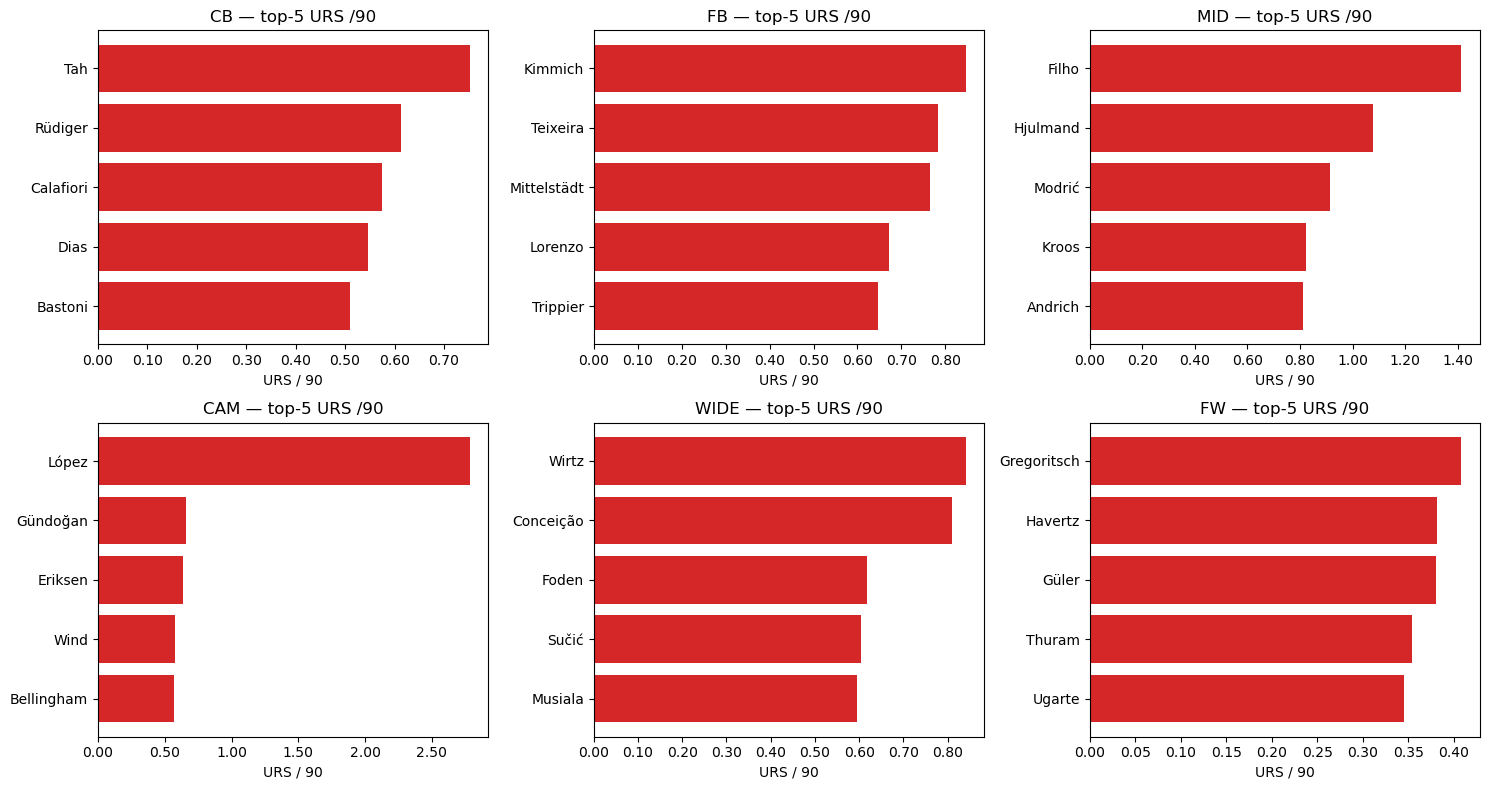

In [14]:
import matplotlib.ticker as mticker
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, role in enumerate(ROLE_ORDER):
    ax = axes[i]
    sub = elig[elig['macro_role'] == role].nlargest(5, 'urs_per90')
    if sub.empty:
        ax.set_visible(False); continue
    ax.barh(sub['player'].str.split().str[-1][::-1],
            sub['urs_per90'][::-1], color='#d62728')
    ax.set_title(f'{role} — top-5 URS /90')
    ax.set_xlabel('URS / 90')
    ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
plt.tight_layout(); plt.show()

## Section 7 — Archetype scatter: Off-Ball Potential vs Latency

Each point is a player; colour encodes macro-role. The two axes are the **independent** factors of URS:

* **Off-Ball Potential /90** (x), how much off-ball value the player exposes
* **Latency = 1 − Capitalisation** (y), what share of that value is left on the table

The product `Potential × Latency` gives URS /90 directly. Iso-URS curves are hyperbolas; we draw three reference contours.

* **Top-right** = high Potential and high Latency, shadow runners (the H3 archetype).
* **Bottom-right** = high Potential, low Latency, trusted threats whose value is realised.
* **Left half** = peripheral off-ball contribution regardless of capitalisation.

The map separates the two stories cleanly. Pedri sits alone in the top-right corner, very high potential and very high latency: he exposes more dangerous space than anyone and is served on barely 16% of it, the extreme shadow runner of the tournament. Jorginho, Hjulmand and Modrić form the next cluster out to the right, high potential at a middling latency around 0.55: heavily involved off the ball and only partly used. The cloud most players live in sits at potential below 1.0 and latency near 0.55, so the axis that actually moves a player out of the pack is exposure, while latency stays in a narrow band for almost everyone. 

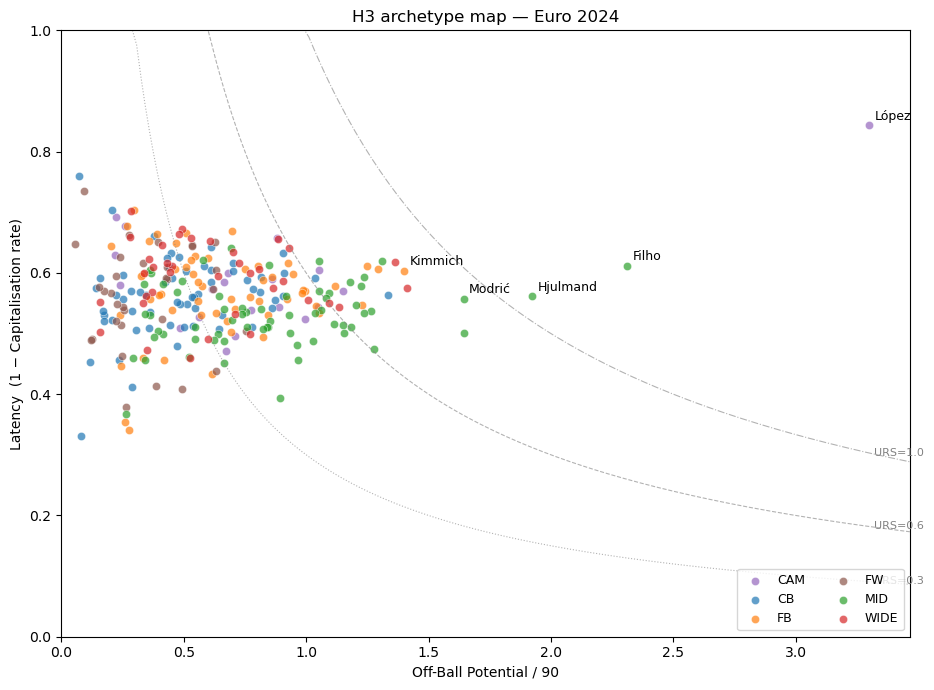

In [15]:
ROLE_COLORS = {'CB':'#1f77b4', 'FB':'#ff7f0e', 'MID':'#2ca02c',
               'CAM':'#9467bd', 'WIDE':'#d62728', 'FW':'#8c564b'}

fig, ax = plt.subplots(figsize=(9.5, 7))
for role, sub in elig.groupby('macro_role'):
    ax.scatter(sub['off_ball_potential_per90'], sub['latency_rate'],
               c=ROLE_COLORS.get(role, 'grey'), label=role,
               s=35, alpha=0.7, edgecolors='white', linewidths=0.4)

# Iso-URS reference contours (URS = Pot · Lat = const).
import numpy as np
x_max = elig['off_ball_potential_per90'].max() * 1.05
xs = np.linspace(0.05, x_max, 200)
for urs_lvl, ls in [(0.3, ':'), (0.6, '--'), (1.0, '-.')]:
    ys = np.clip(urs_lvl / xs, 0, 1)
    ax.plot(xs, ys, ls, color='grey', lw=0.8, alpha=0.6)
    # label at the right edge
    xi = x_max * 0.95
    yi = urs_lvl / xi
    if 0 < yi < 1:
        ax.text(xi, yi, f'  URS={urs_lvl}', fontsize=8, color='grey', va='center')

# Annotate the top-5 by URS /90
for _, r in elig.nlargest(5, 'urs_per90').iterrows():
    ax.annotate(r['player'].split()[-1],
                (r['off_ball_potential_per90'], r['latency_rate']),
                xytext=(4, 4), textcoords='offset points', fontsize=9)

ax.set_xlabel('Off-Ball Potential / 90')
ax.set_ylabel('Latency  (1 − Capitalisation rate)')
ax.set_title('H3 archetype map — Euro 2024')
ax.set_xlim(0, x_max); ax.set_ylim(0, 1)
ax.legend(loc='lower right', fontsize=9, ncol=2)
plt.tight_layout(); plt.show()

## Section 8 — Off-ball radar (profile behind the URS index)

URS /90 is the headline index; its within-role percentile is the H3 player rating. The radar does not repeat it but profiles what sits behind it, on three within-role-percentile axes (outside = better):

* **Off-Ball Potential /90**: volume × quality of off-ball exposure
* **xEPV mean**: quality of the average frame, separating "few great runs" from "many decent ones"
* **Latency (1 − Cap.)**: share of the offered value left uncapitalised

A shadow runner reads high on all three; a trusted threat has Potential and xEPV mean high but Latency low; a peripheral player is low everywhere.

Highest URS /90: Pedro González López


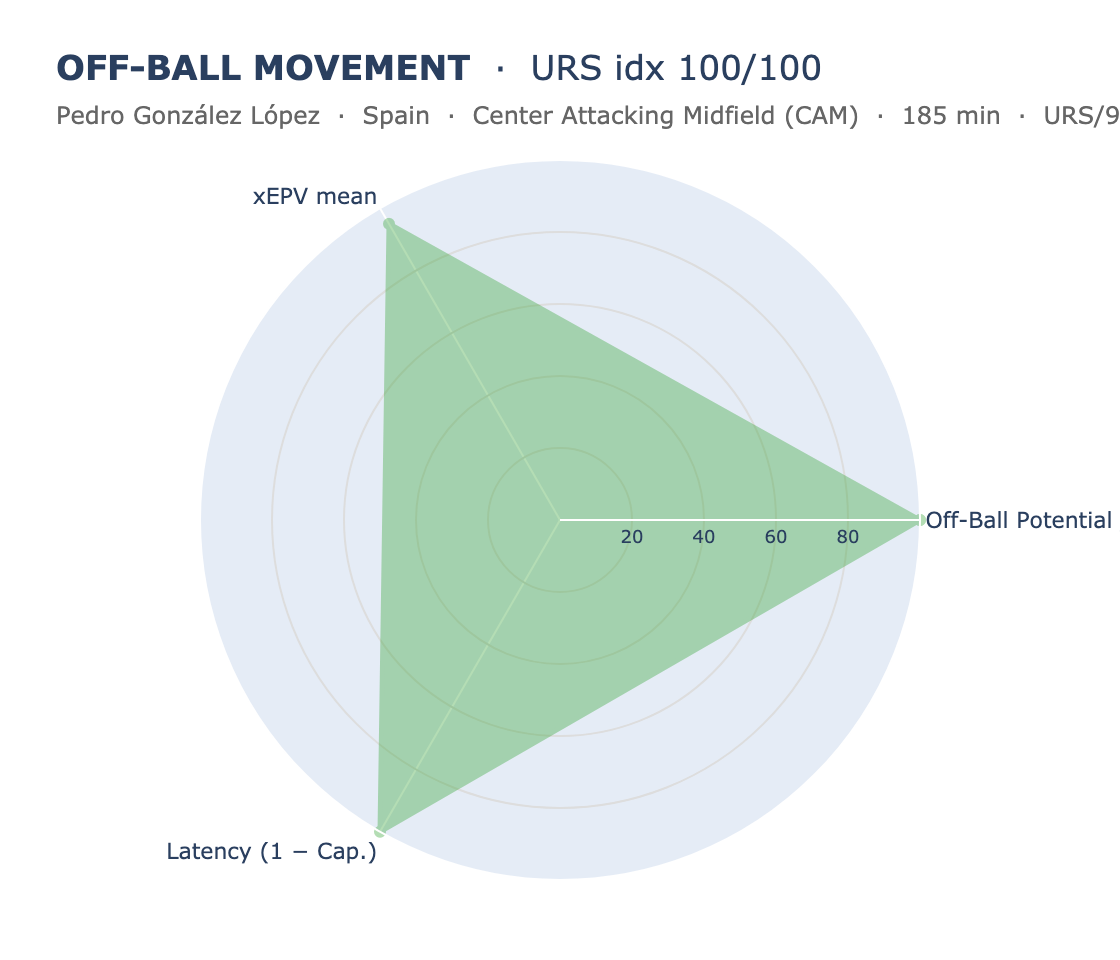

In [16]:
# Example: the URS /90 leader (the H3 archetype headline player)
from src.urs import off_ball_radar

top_player = elig.nlargest(1, 'urs_per90').iloc[0]['player']
print(f"Highest URS /90: {top_player}")
off_ball_radar(top_player)

### 8.1 — Head-to-head: shadow runner vs trusted threat

We compare the player with the lowest Capitalisation rate among the top-10 by Off-Ball Potential (shadow-runner candidate) against the one with the highest (trusted threat). Both produce a lot of off-ball value; only one sees that value realised.

The pairing the data picks is Pedri against Kroos, and it is the cleanest illustration of the metric. Both are near the top on Off-Ball Potential, so on the volume axis they look alike. The difference is latency: Pedri is served on 16% of the value he offers and Kroos on 50%. On the radar the two polygons sit on top of each other on Potential and pull apart entirely on the Latency axis, Pedri stretched to the edge, Kroos pulled in. Same exposure, opposite outcome: one is a threat his team keeps missing, the other a threat his team uses. URS /90 rewards the first, and that is the behaviour H3 is built to surface.

Shadow runner candidate : Pedro González López
Trusted threat candidate: Toni Kroos


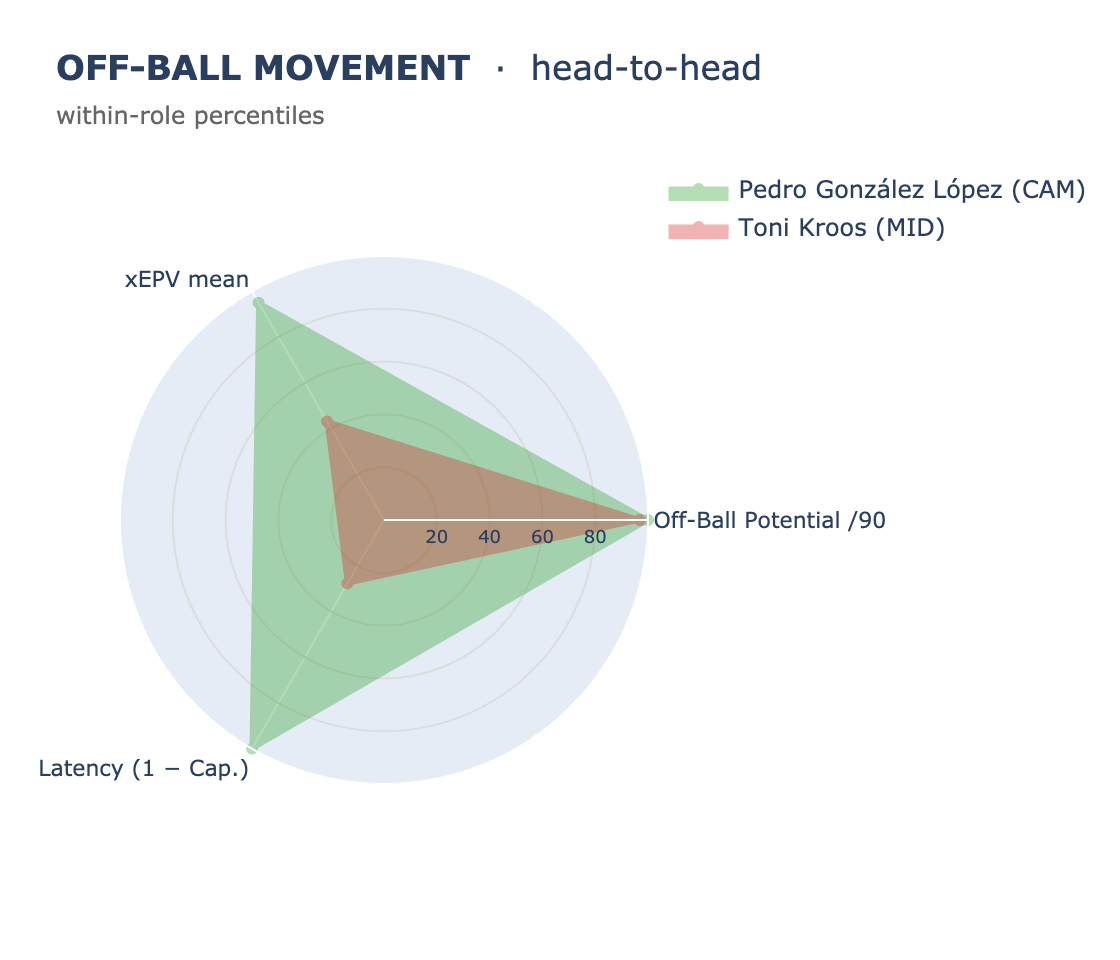

In [17]:
# Compare a shadow-runner candidate against a trusted-threat candidate.
# Choose the player with the lowest capitalisation_rate among the top-10
# Potential players (≈ shadow runner) and the one with the highest among them.
top10 = elig.nlargest(10, 'off_ball_potential_per90')
shadow  = top10.loc[top10['capitalization_rate'].idxmin(), 'player']
trusted = top10.loc[top10['capitalization_rate'].idxmax(), 'player']
print(f"Shadow runner candidate : {shadow}")
print(f"Trusted threat candidate: {trusted}")
off_ball_radar([shadow, trusted])

### 8.2 — Correlation among the axes

The three axes share xEPV in their numerator, so some correlation is expected. The Spearman matrix below quantifies it. Off-Ball Potential is correlated with the URS index by construction (`URS = Potential × Latency`, and Potential carries the wider spread), so it is kept as the most readable volume axis rather than treated as independent signal. Latency and xEPV mean carry the information that actually separates two players with the same URS into different profiles.

The matrix confirms the three axes are doing different jobs. Potential and Latency are essentially uncorrelated (ρ ≈ −0.01): how much space a player exposes says nothing about whether it gets used, which is exactly why the archetype scatter in §7 spreads players across two real dimensions rather than one diagonal. xEPV mean correlates only weakly with Potential (ρ ≈ 0.30) and with Latency (ρ ≈ 0.18), so it adds a quality reading that neither volume nor capitalisation already contains. None of the off-diagonal values is high enough to call any axis redundant, so the three-axis radar profiles the player without repeating itself.

In [18]:
from scipy.stats import spearmanr
metric_cols = ['off_ball_potential_per90', 'xepv_mean', 'latency_rate']
labels = ['Potential /90', 'xEPV mean', 'Latency']
sub = elig[metric_cols].dropna()
rho_mat = sub.corr(method='spearman')
rho_mat.index = labels; rho_mat.columns = labels
rho_mat.round(2)

,Potential /90,xEPV mean,Latency
Potential /90,1.00,0.30,-0.01
xEPV mean,0.30,1.00,0.18
Latency,-0.01,0.18,1.00


## Section 9 — Visual proof: top uncapitalised runs (top-3 by URS /90)

Pitch-level renders of the four highest-URS events for each of the top-3 players by URS /90. Each panel reads simply:

* **cyan dot** = the ball-carrier (the teammate who has possession),
* **gold arrow** = where the pass actually went,
* **green dot** = the highlighted candidate, the player who made the high-value off-ball run that was not served (this is the run the URS event credits),
* **grey dots** = the other visible teammates, shown for context,
* **dashed red shape** = the opposing block (convex hull of the visible defenders).

We keep the teammates a neutral grey on purpose: the gold arrow already shows where the ball went, so the eye should go straight to the green candidate.

The point of this section is twofold:

1. **Confirm the resolver placed the highlighted candidate in a plausible spot.** If the receiver name attached to the green dot does not fit the play, the URS attribution is suspect.
2. **Read the off-ball value with our own eyes.** A green candidate in a dangerous zone that was bypassed for a safer option is exactly the H3 archetype playing out in a single frame.

Top-3 URS /90 — visual proof for each:
                 player    team macro_role  urs_per90
   Pedro González López   Spain        CAM   2.784016
Jorge Luiz Frello Filho   Italy        MID   1.413770
        Morten Hjulmand Denmark        MID   1.079234


=== Pedro González López  (Spain, CAM) — URS /90 = 2.784 ===


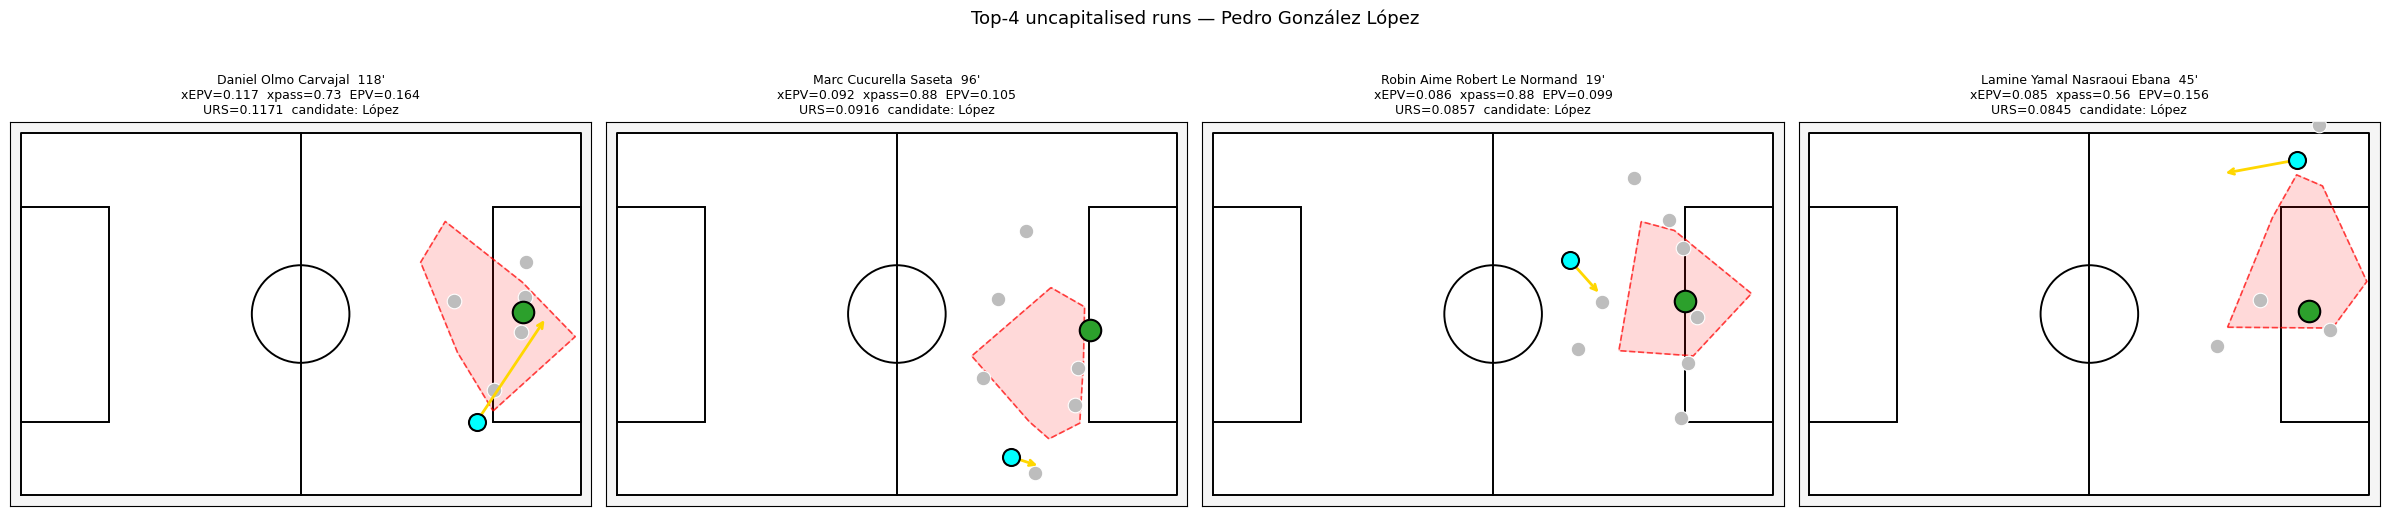


=== Jorge Luiz Frello Filho  (Italy, MID) — URS /90 = 1.414 ===


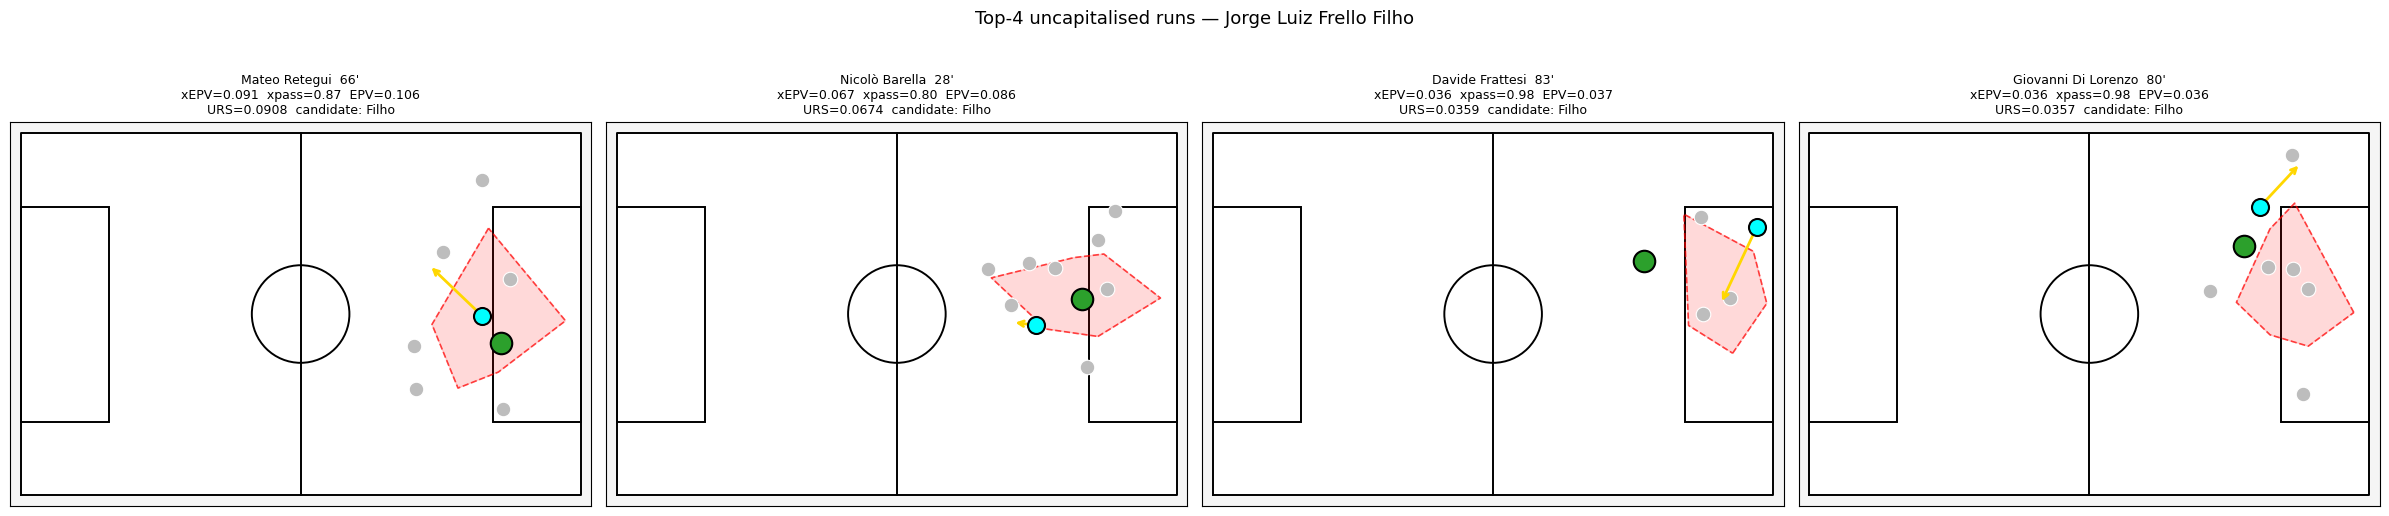


=== Morten Hjulmand  (Denmark, MID) — URS /90 = 1.079 ===


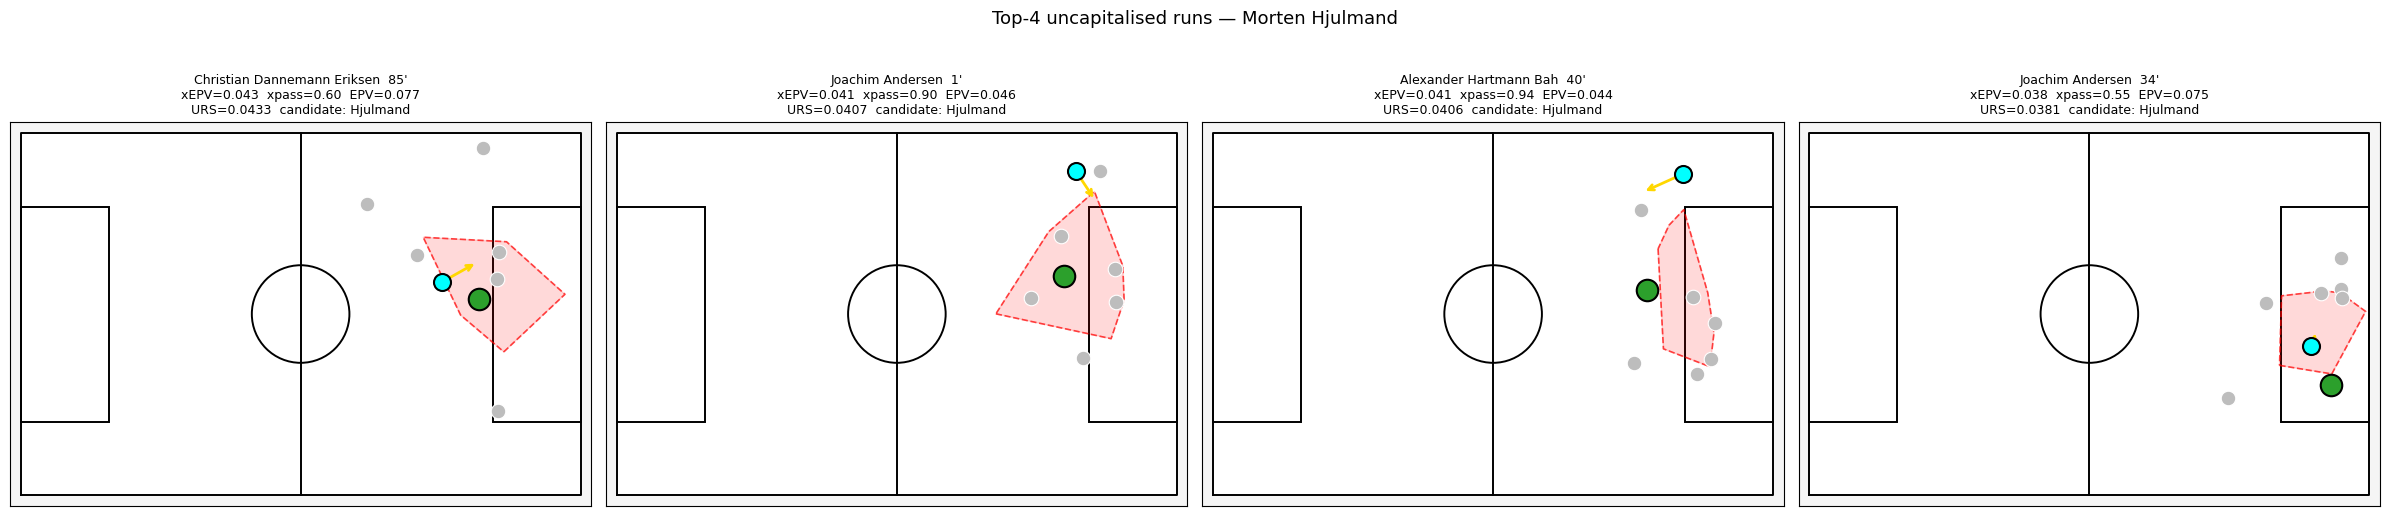

In [19]:
from src.urs import show_uncapitalised_runs

top3 = elig.nlargest(3, 'urs_per90')[['player', 'team', 'macro_role', 'urs_per90']]
print("Top-3 URS /90 — visual proof for each:")
print(top3.to_string(index=False))
print()

for _, row in top3.iterrows():
    print(f"\n=== {row['player']}  ({row['team']}, {row['macro_role']}) — URS /90 = {row['urs_per90']:.3f} ===")
    show_uncapitalised_runs(row['player'], n=4)

## Section 10 — Split-half reliability of URS_per90

Spearman ρ between the **first half of the tournament calendar and the second half**, not the two halves of a single match. The 51 matches are ordered by date and split in two (the first 25 against the last 26); each player gets an URS /90 computed on each block, and we correlate the two rankings. Minutes per block are recomputed with the same H1 formula (`events.minute.max − events.minute.min`) summed over the matches of that block, so the split-half pool is consistent with the main URS pool.

The ranking reproduces: ρ = 0.72 on the 117 players who clear the minutes floor in both blocks. A player's URS over the opening matches predicts his URS over the closing ones, so the order is a stable signal rather than noise off a single hot game. It is the right magnitude for a per-90 off-ball metric on half a tournament, in the same range as H1's and H2's reliability checks, and high enough to read the within-role tops as real rather than sampling artefacts.

  URS_per90 — split-half reliability
  Matches first half  : 25
  Matches second half : 26
  Players in both     : 117
  Spearman rho        : 0.722
  p-value             : 0.0000
  rho >= 0.50 — URS_per90 shows stable inter-half agreement.


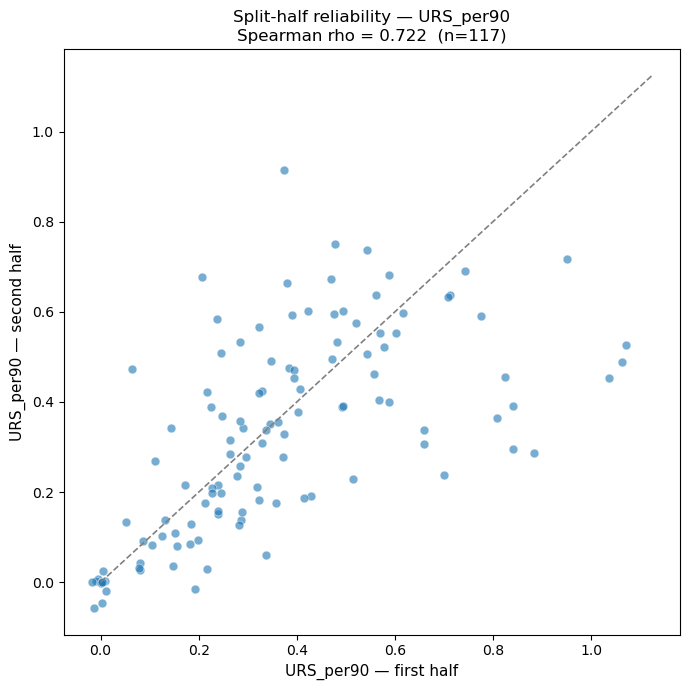

In [20]:
from src.urs import split_half_reliability
split_half_reliability(min_minutes_per_half=135)

## Conclusion

**URS /90 is the H3 headline**: latent off-ball EPV that teammates leave unrealised, in the same units as H1 and H2. It factors into *Off-Ball Potential /90* (value exposed) × *Latency* (share left on the table), the two axes of the §7 archetype map; the §8 radar profiles which kind of off-ball player produces a given URS.

- **Resolver gate passed.** The full-tournament validation (§1.3) clears the 85 % accuracy-on-confident bar, so the per-player Tier 1 ranking is the one reported. Parameters are calibrated in §1.4: a 5 s position window and an 8 m confidence threshold.
- **Reading is within-role** (§6). The absolute board is structurally MID-heavy — midfielders appear in more frames and occupy higher-EPV zones — so players are ranked against their own position.
- **Stability.** Split-half reliability (§10) and the `RECEIVED_WINDOW_S` N-sweep (§1.4.2) confirm the ranking reproduces and does not hinge on the window choices.

*Caveats.* URS rests on resolver-confident candidates and a 4 s receipt window (~1 s above the empirical P95, §1.4.2). It measures offered value left unserved, not who is responsible for not serving it.